### Converting a list of custom positions to JSONL format 

Although the lichess puzzle database is quite extensive, many of the puzzles do not focus on opening principles. Even when testing on tens of thousands of data points, my best agent still had problems with positional play. 

In the image below, my agent responded to Nf3 with Na6. An important rule in chess is that you want to develop your knights toward the center, so they have increased mobility. Knights and bishops on the side files are generally problematic. 

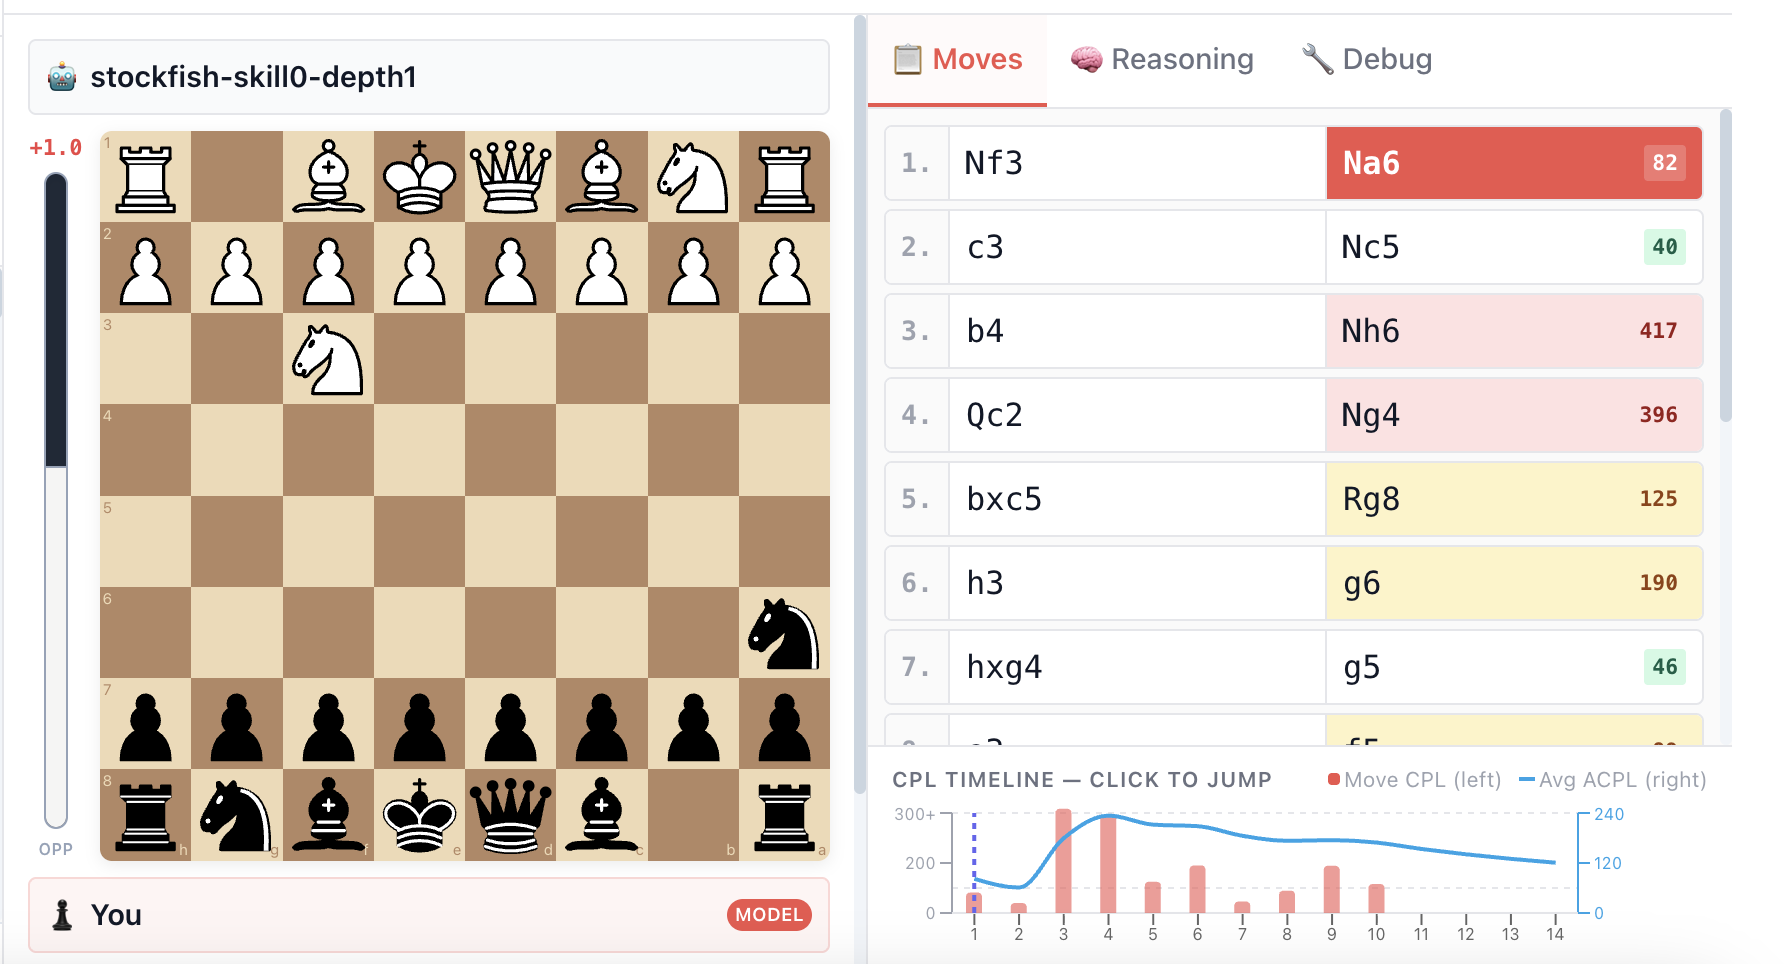

To fix this problem, I generated a set of FENs to account for these cases, so that the agent knows what to do if they blunder in the beginning. We are going to convert these FENs into the JSONL format and combine them with the larger data. 

In [1]:
# import relevant libraries 
import pandas as pd
import configure_lichess_csv as cfg

In [2]:
new_data = pd.read_csv("side_knights.csv", header=None)

We want to feed our data to the model using an instruction-input-output format. We can create the input and output columns as functions of the FEN data. The instruction prompt will be the same for every row, so we can simply append the same message for each row. 

In [3]:
new_data["instruction"] = "Select the best move for this position. Please justify your reasoning in 1 or 2 sentences."

For the input, we will include the FEN and the set of possible legal moves that can be made. 

In [4]:
# create a LegalMoves column 
new_data["LegalMoves"] = new_data.iloc[:, 0].apply(cfg.get_all_legal_moves)

In [5]:
# combine this with the FEN to create an input column
new_data["input"] = (
    "FEN: " + new_data.iloc[:, 0].astype(str) +
    "\nLegal Moves: " + new_data["LegalMoves"].apply(lambda x: ", ".join(x))
) 

In [6]:
# view the first row to see what our input looks like 
new_data.iloc[0]["input"]

'FEN: rnbqkbnr/1ppppppp/p7/8/8/N7/PPPPPPPP/R1BQKBNR w KQkq - 0 2\nLegal Moves: a3b5, a3c4, a3b1, g1h3, g1f3, a1b1, h2h3, g2g3, f2f3, e2e3, d2d3, c2c3, b2b3, h2h4, g2g4, f2f4, e2e4, d2d4, c2c4, b2b4'

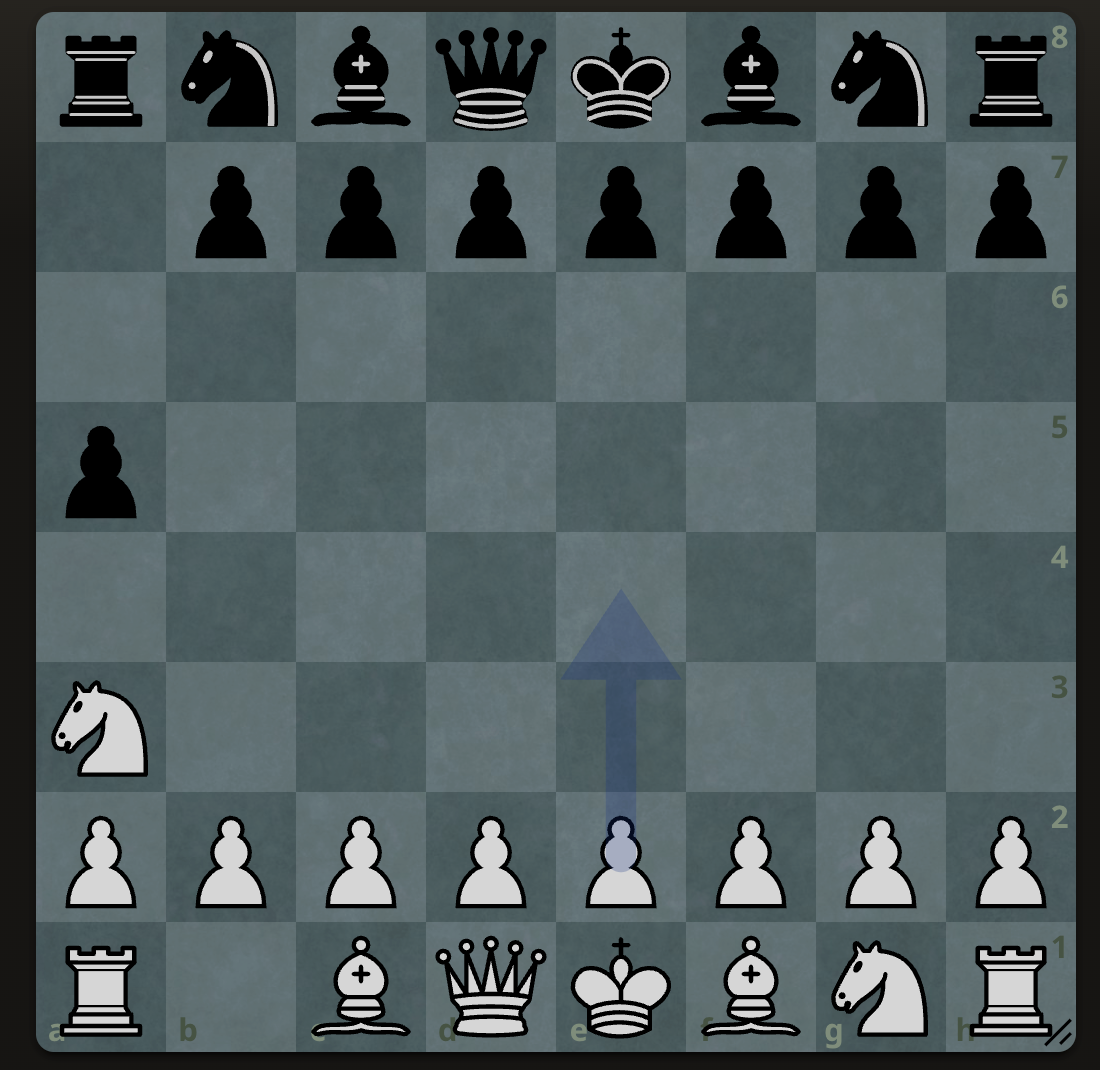
*A visualization of the given FEN, with the best move indicated by the arrow. e2e4 is within the set of legal moves, so we know this function worked properly!*

In [7]:
# find the best move from the set of legal moves for training 
new_data["BestMove"] = new_data.iloc[:, 0].apply(cfg.get_best_move)

**NOTE:** The `get_best_move()` function has O(n) complexity, meaning that the time depends on the number of rows. For 40 rows, the function ran for 10.3 seconds. 

In [8]:
# format the output in <uci_move>your_move</uci_move> format 
new_data["output"] = new_data["BestMove"].apply(cfg.format_output)

In [9]:
# preview the new data frame 
new_data.head()

,0,instruction,LegalMoves,input,BestMove,output
0,rnbqkbnr/1ppppppp/p7/8/8/N7/PPPPPPPP/R1BQKBNR ...,Select the best move for this position. Please...,"[a3b5, a3c4, a3b1, g1h3, g1f3, a1b1, h2h3, g2g...",FEN: rnbqkbnr/1ppppppp/p7/8/8/N7/PPPPPPPP/R1BQ...,e2e4,<uci_move>e2e4</uci_move>
1,rnbqkbnr/1ppppppp/8/p7/8/N7/PPPPPPPP/R1BQKBNR ...,Select the best move for this position. Please...,"[a3b5, a3c4, a3b1, g1h3, g1f3, a1b1, h2h3, g2g...",FEN: rnbqkbnr/1ppppppp/8/p7/8/N7/PPPPPPPP/R1BQ...,e2e4,<uci_move>e2e4</uci_move>
2,rnbqkbnr/p1pppppp/1p6/8/8/N7/PPPPPPPP/R1BQKBNR...,Select the best move for this position. Please...,"[a3b5, a3c4, a3b1, g1h3, g1f3, a1b1, h2h3, g2g...",FEN: rnbqkbnr/p1pppppp/1p6/8/8/N7/PPPPPPPP/R1B...,d2d4,<uci_move>d2d4</uci_move>
3,rnbqkbnr/p1pppppp/8/1p6/8/N7/PPPPPPPP/R1BQKBNR...,Select the best move for this position. Please...,"[a3b5, a3c4, a3b1, g1h3, g1f3, a1b1, h2h3, g2g...",FEN: rnbqkbnr/p1pppppp/8/1p6/8/N7/PPPPPPPP/R1B...,a3b5,<uci_move>a3b5</uci_move>
4,rnbqkbnr/pp1ppppp/2p5/8/8/N7/PPPPPPPP/R1BQKBNR...,Select the best move for this position. Please...,"[a3b5, a3c4, a3b1, g1h3, g1f3, a1b1, h2h3, g2g...",FEN: rnbqkbnr/pp1ppppp/2p5/8/8/N7/PPPPPPPP/R1B...,e2e4,<uci_move>e2e4</uci_move>


For the final JSONL file, we only want the instruction, input, and output columns. 

In [10]:
# export data to jsonl file in model-response form
new_data[["instruction", "input", "output"]].to_json(
    "new_data.jsonl", # make sure to include the correct extension! 
    orient="records",
    lines=True, # verifies data will be in JSONL format
    force_ascii=False # setting false allows for \ characters
)